We have already modeled - using Ridge Regression - `Revenue per Order`, now as we head to Classification-based modeling, I would like to stop and statistically test first the prime target variable in consideration for that part: `customer_value_quintile`.

Potential paths ahead:

* We can then classify customers into even better categories and use the predictive modeling of the continuous variable (Revenue) on top of them.

---

In [1]:
# Install nbimporter
!pip install nbimporter

# This library allows us to treat a ".ipynb" file like a Python module
import nbimporter

In [2]:
import pandas as pd
import requests
import nbimporter

pd.set_option('display.max_columns', None)

from google.colab import drive
drive.mount('/content/drive')

import sys

sys.path.append("/content/drive/MyDrive/Enterprise AI Customer Churn Prediction Platform/utils")

# Defining the URL for the Customer Features Dataset
url = "https://raw.githubusercontent.com/alijrizvi/enterprise-ai-customer-churn-prediction-platform/main/data/gold_ml-ready_customer-features.csv"

Mounted at /content/drive


In [9]:
# Data Loading

# Importing Functions from '03_01_customer_segmentation.ipynb' using 'nbimporter'
from data_loader import load_gold_ml_dataset, load_customer_churn_data, clean_customer_churn_data

df = load_customer_churn_data(url)
df = clean_customer_churn_data(df)

df.sample(5)

✓ Successfully loaded 300 records.


,customerID,customer_value_quintile,total_transactions,lifetime_spend,avg_transaction_value,avg_unit_price,total_items,avg_items_per_transaction,unique_products,unique_franchises,payment_method_diversity,first_purchase,last_purchase,recency_days,customer_lifetime_days,avg_days_between_purchases,active_days,active_months,revenue_per_order,avg_basket_size,avg_monthly_spend,multi_franchise_customer,high_value_customer,churn_label
141,2000141,1,12,309,25.75,3,103,8.58,4,11,3,2024-05-01T00:28:26.675Z,2024-05-12T23:30:04.431Z,788,11,1.00,10,1,25.75,8.58,309,1,1,1
176,2000176,2,8,243,30.38,3,81,10.13,4,8,3,2024-05-01T04:04:04.187Z,2024-05-13T06:08:42.087Z,787,12,1.71,6,1,30.38,10.13,243,1,1,1
220,2000220,5,10,129,12.90,3,43,4.30,4,10,3,2024-05-03T01:51:47.551Z,2024-05-17T01:03:35.428Z,783,14,1.56,8,1,12.90,4.30,129,1,0,1
223,2000223,5,11,138,12.55,3,46,4.18,6,10,3,2024-05-05T09:32:28.704Z,2024-05-16T18:03:28.903Z,784,11,1.10,7,1,12.55,4.18,138,1,0,1
298,2000298,1,12,297,24.75,3,99,8.25,4,10,3,2024-05-01T21:25:35.354Z,2024-05-17T07:36:31.729Z,783,16,1.45,9,1,24.75,8.25,297,1,1,1




---

## Hypothesis Testing using **ANOVA** for Another Business Problem

* Using Regression, predictive modeling on customers' **lifetime expenditure** (i.e., revenue generated for the business) was done.
* Now, let us evaluate ***whether segmenting customers into different categories (i.e., quintiles) was objectively justified and relevant or not***.
* Then, we can move on to **predicting customer churn risk** using tree-based algorithms (Random Forest Classifier, XGBoost Classifier).

In [20]:
# Data Cleaning for the Independent variable: 'customer_value_quintile'

# Ensuring 'customer_value_quintile' is of a numeric type to prevent filtering issues for ANOVA

# Converting 'customer_value_quintile' to numeric, coercing errors to NaN, and then Drop any NaNs
df['customer_value_quintile'] = pd.to_numeric(df['customer_value_quintile'], errors = 'coerce')
df.dropna(subset=['customer_value_quintile'], inplace = True)

# Converting to integer type after handling NaNs
df['customer_value_quintile'] = df['customer_value_quintile'].astype(int)

print(f"Data type of 'customer_value_quintile' after cleaning: {df['customer_value_quintile'].dtype}")
print(df['customer_value_quintile'].value_counts().sort_index())

Data type of 'customer_value_quintile' after cleaning: int64
customer_value_quintile
1    60
2    60
3    60
4    60
5    60
Name: count, dtype: int64


In [22]:
# Forming the needed Dataset
lifetime_spend_by_quintile = df[['customer_value_quintile', 'lifetime_spend']]
groups = lifetime_spend_by_quintile.groupby('customer_value_quintile').groups

# Extracting Individual Groups (Customer Quintiles) as Series of 'lifetime_spend'
quintile_1 = lifetime_spend_by_quintile[avg_items_by_quintile['customer_value_quintile'] == 1]['lifetime_spend']
quintile_2 = lifetime_spend_by_quintile[avg_items_by_quintile['customer_value_quintile'] == 2]['lifetime_spend']
quintile_3 = lifetime_spend_by_quintile[avg_items_by_quintile['customer_value_quintile'] == 3]['lifetime_spend']
quintile_4 = lifetime_spend_by_quintile[avg_items_by_quintile['customer_value_quintile'] == 4]['lifetime_spend']
quintile_5 = lifetime_spend_by_quintile[avg_items_by_quintile['customer_value_quintile'] == 5]['lifetime_spend']

In [24]:
# One-Way ANOVA to see if Statistically Significant differences exist between different Customer Categories

from scipy import stats

stats.f_oneway(quintile_1, quintile_2, quintile_3, quintile_4, quintile_5)

F_onewayResult(statistic=np.float64(446.71868074882696), pvalue=np.float64(8.561374978436862e-124))

### Interpretation of A/B Test Results

*   **T-statistic:** This value measures the size of the difference relative to the variation in your sample data. A larger absolute t-statistic indicates a greater difference between the group means.


*   **P-value:** This value indicates the probability of observing such a difference between the groups if there were truly no difference in the population (i.e., if the null hypothesis were true).

    *   The p-value is less than the standard significance level (0.05). So, *we reject the **Null Hypothesis*** and conclude that there is a **statistically significant** difference in "Average Items bought per purchase" between Customers in each classified Quintile.



---

### Digging Deeper: **Tukey's HSD** Test to Dissect and Analyze the Details of the Differences in Product Count Bought per Customer Quintile/Category

  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower     upper   reject
-------------------------------------------------------
     1      2    -99.3   0.0 -116.9279  -81.6721   True
     1      3   -155.7   0.0 -173.3279 -138.0721   True
     1      4   -197.3   0.0 -214.9279 -179.6721   True
     1      5  -249.85   0.0 -267.4779 -232.2221   True
     2      3    -56.4   0.0  -74.0279  -38.7721   True
     2      4    -98.0   0.0 -115.6279  -80.3721   True
     2      5  -150.55   0.0 -168.1779 -132.9221   True
     3      4    -41.6   0.0  -59.2279  -23.9721   True
     3      5   -94.15   0.0 -111.7779  -76.5221   True
     4      5   -52.55   0.0  -70.1779  -34.9221   True
------------------------------------------------------- 



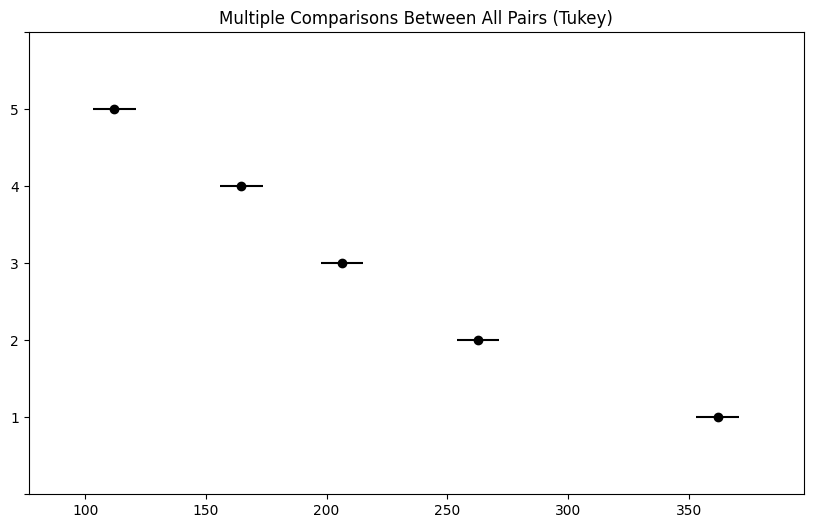

In [25]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey's HSD test
tukey = pairwise_tukeyhsd(endog = lifetime_spend_by_quintile['lifetime_spend'],
                                  groups = lifetime_spend_by_quintile['customer_value_quintile'],
                                  alpha = 0.05)

tukey.plot_simultaneous() # Plotting Group CIs
print(tukey.summary(), '\n') # "meandiff" = mean(group2) - mean(group1)

/tmp/ipykernel_3129/3056836348.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x = 'customer_value_quintile', y = 'lifetime_spend', data = df, palette = 'Set3')


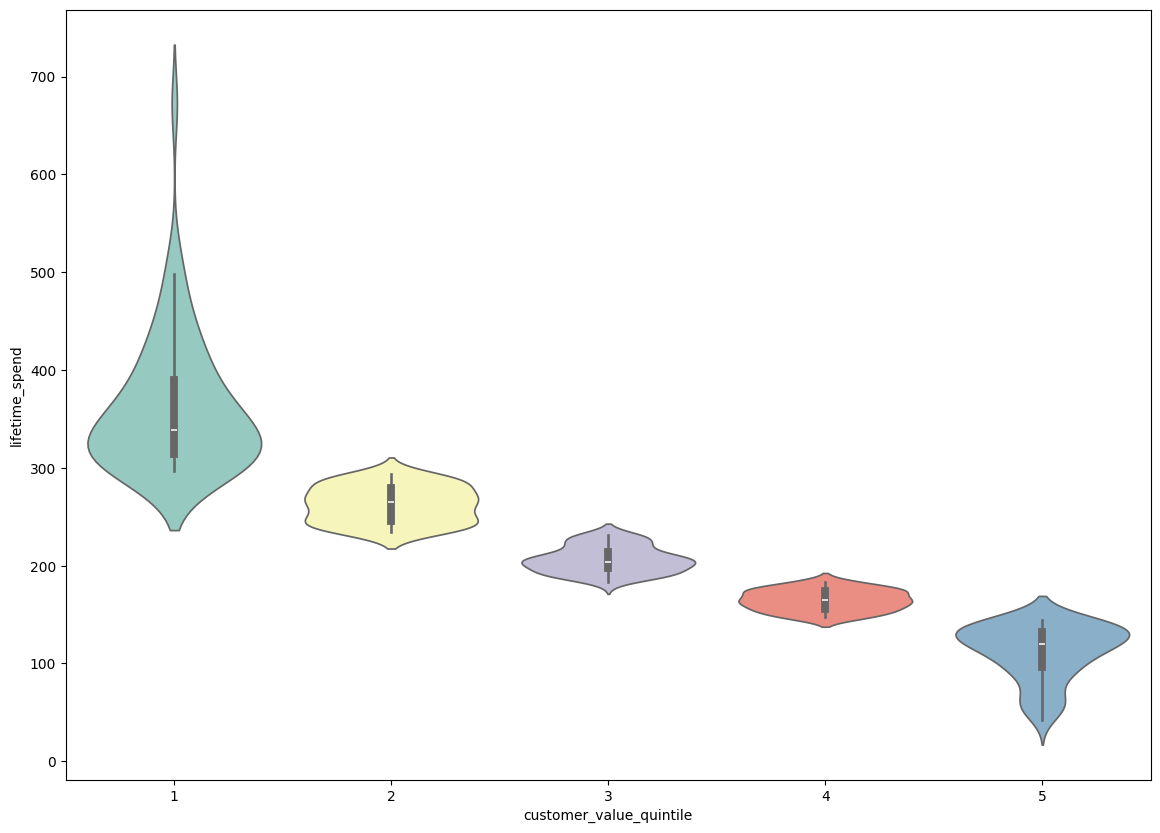

In [26]:
# Visualizing the Differences between Customer Quintiles and respective Lifetime Expenditure

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (14, 10))
sns.violinplot(x = 'customer_value_quintile', y = 'lifetime_spend', data = df, palette = 'Set3')
plt.show()